In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

In [2]:
TICKERS = [

    'NVDA', 'GOOG', 'GOOGL', 'AAPL', 'MSFT', 'AMZN', 'AVGO', 'TSLA',
    'META', 'WMT', 'BRK-B', 'LLY', 'MU', 'JPM', 'AMD', 'XOM', 'V',
    'INTC', 'JNJ', 'ORCL', 'COST', 'CSCO', 'MA', 'CAT', 'CVX', 'ABBV',
    'NFLX', 'LRCX', 'BAC', 'KO', 'UNH', 'AMAT', 'PG',  'GE',
    'MS', 'HD', 'PM', 'GS', 'MRK', 'TXN', 'RTX', 'LIN', 'WFC',
    'C', 'QCOM', 'IBM', 'AXP', 'TMUS', 'PEP', 'VZ', 'MCD', 'NEE', 'DIS',
    'AMGN', 'BA', 'T', 'BLK', 'TMO', 'GILD', 'ISRG', 'UNP', 'SCHW',
    'ABT',  'DE', 'COP', 'CRM', 'PFE', 'HON', 'LOW', 'MO',
    'BKNG', 'SBUX', 'DHR', 'LMT', 'BMY', 'CVS', 'COF', 'ACN', 'NOW',
    'INTU', 'SO', 'ADBE', 'MDT', 'DUK', 'FDX', 'GD', 'CMCSA', 'AMT',
    'USB', 'UPS', 'MDLZ', 'MMM', 'EMR', 'CL', 'GM', 'SPG', 'NKE'
]

BENCHMARK = '^OEX'

END_DATE = datetime(2026, 5, 21)
START_DATE = END_DATE - timedelta(days=10 * 365)

In [3]:
all_tickers = TICKERS + [BENCHMARK]
data = yf.download(all_tickers, start=START_DATE, end=END_DATE, interval='1wk', auto_adjust=True)

[*********************100%***********************]  98 of 98 completed


In [4]:
prices = data['Close']
returns = prices.pct_change().dropna()
returns

Ticker,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM,^OEX
Date,,,,,,,,,,,,,,,,,,,,,
2016-05-30,-0.024216,0.036517,-0.003054,-0.000336,-0.014380,0.002331,-0.095652,0.015631,0.008580,0.018674,...,0.021194,0.048052,0.001359,-0.013504,0.003515,0.005926,-0.012979,0.001696,-0.018221,-0.002184
2016-06-06,0.009294,-0.061539,-0.019908,-0.005299,-0.016312,-0.013120,0.038462,-0.027703,0.017015,-0.010516,...,0.017539,0.027784,0.013576,-0.009677,0.003003,0.034368,-0.036860,0.003810,0.018219,-0.000766
2016-06-13,-0.035414,-0.016229,-0.026302,-0.005919,-0.015553,-0.026589,0.217593,-0.033338,-0.017006,-0.016047,...,-0.011132,-0.013517,0.004784,-0.020257,-0.039786,0.021075,-0.035995,-0.002671,0.008224,-0.012733
2016-06-20,-0.020246,-0.002500,0.013908,-0.052054,-0.035363,-0.008536,-0.072243,-0.021187,0.017448,-0.010518,...,0.001635,-0.026604,-0.005808,-0.030406,-0.025198,0.012087,-0.019098,0.014235,-0.014661,-0.015782
2016-06-27,0.026660,0.047611,0.042996,0.018573,0.033840,0.028411,0.038934,0.053466,0.049229,0.038228,...,0.026003,0.024516,0.037831,0.005017,-0.007595,0.033070,0.028878,0.011812,0.049782,0.032393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,0.003071,-0.038494,-0.052766,-0.097597,0.004050,0.050637,0.249362,-0.030256,-0.012993,0.053600,...,0.093306,0.069921,0.005449,-0.023713,-0.023973,-0.003652,-0.024444,0.018980,0.016867,0.007120
2026-04-27,0.033498,0.039706,-0.018325,0.008242,0.021472,-0.067044,0.036600,-0.042751,0.019079,0.016175,...,0.039051,-0.008857,0.005139,0.012954,0.060145,0.037301,0.017502,0.012931,0.025787,0.012308
2026-05-04,0.047048,-0.024443,-0.057456,0.003281,0.009294,0.119153,0.262523,0.005700,-0.027972,0.016476,...,0.030370,-0.006271,-0.063122,-0.013677,-0.028168,-0.018499,-0.063977,-0.008891,-0.053552,0.030437


In [5]:
asset_returns = returns[TICKERS]
benchmark_returns = returns[BENCHMARK]

In [6]:
from scipy.optimize import minimize

In [19]:
def sparse_tracking_weights_irl1(assets_train, bench_train, lambda_val, q, n_starts=10, max_iter=50, tol=1e-6,eps=1e-6,
                                 ridge=1e-5,dirichlet_alpha=0.2,threshold=1e-4, random_state=42):


    np.random.seed(random_state)
    R = assets_train.values
    RB = bench_train.values.reshape(-1, 1)
    T, N = R.shape
    Z = R - RB
    Sigma = np.cov(Z, rowvar=False)
    Sigma += ridge * np.eye(N)
    constraints = [
        {
            'type': 'eq',
            'fun': lambda w: np.sum(w) - 1
        }
    ]
    bounds = [(0, 1)] * N
    best_obj = np.inf
    best_w = None
    for start in range(n_starts):
        w = np.random.dirichlet(dirichlet_alpha * np.ones(N))
        for iteration in range(max_iter):
            w_old = w.copy()
            alpha = q / ((np.abs(w_old) + eps) ** (1 - q))

            def objective(x):
                var_term = x @ Sigma @ x
                l1_term = lambda_val * np.sum(alpha * np.abs(x))
                return var_term + l1_term

            result = minimize(objective,w_old,method='SLSQP',bounds=bounds,constraints=constraints,
                options={'maxiter': 600,'ftol': 1e-9,'disp': False})
            if not result.success:
                break

            w = result.x
            diff = np.linalg.norm(w - w_old)
            if diff < tol:
                break

        final_obj = objective(w)
        if final_obj < best_obj:
            best_obj = final_obj
            best_w = w.copy()


    best_w[np.abs(best_w) < threshold] = 0

    if np.sum(best_w) > 0:
        best_w /= np.sum(best_w)

    return best_w

In [72]:
LAMBDA_LIST = [0.00005]
Q_LIST = [0.5, 0.7]
DIRICHLET_ALPHA_LIST = [0.1, 0.2, 0.3, 0.5]

def select_best_params(assets_train, bench_train, assets_val, bench_val,
                       lambda_list, q_list, dirichlet_alpha_list):

    best_lambda = None
    best_q = None
    best_alpha = None
    best_weights = None
    best_val_tev = np.inf

    total_combinations = len(lambda_list) * len(q_list) * len(dirichlet_alpha_list)
    print(f"Всего комбинаций: {total_combinations}")

    for lam in lambda_list:
        for q in q_list:
            for alpha in dirichlet_alpha_list:
                w = sparse_tracking_weights_irl1(
                    assets_train, bench_train,
                    lam, q,
                    n_starts=10,
                    max_iter=30,
                    tol=1e-5,
                    eps=1e-6,
                    ridge=1e-5,
                    dirichlet_alpha=alpha,
                    threshold=1e-4,
                    random_state=42
                )

                port_val_ret = assets_val.values @ w
                tracking_diff = port_val_ret - bench_val.values
                tev = np.var(tracking_diff)

                if tev < best_val_tev:
                    best_val_tev = tev
                    best_lambda = lam
                    best_q = q
                    best_alpha = alpha
                    best_weights = w

    return best_lambda, best_q, best_alpha, best_weights, best_val_tev

In [74]:
ESTIMATION_WINDOW = 104
VALIDATION_WINDOW = 26
REBALANCE_FREQ = 4
TC_BPS = 10
TOTAL_WINDOW = ESTIMATION_WINDOW + VALIDATION_WINDOW

start_idx = TOTAL_WINDOW
end_idx = len(returns) - REBALANCE_FREQ
rebalance_points = list(range(start_idx, end_idx, REBALANCE_FREQ))

all_weights = []
all_lambdas = []
all_qs = []
all_alphas = []
all_n_active = []
rebalance_dates = []

prev_weights = None
prev_rebalance_idx = None

In [75]:
for i, t in enumerate(rebalance_points):
    train_start = t - TOTAL_WINDOW
    train_end = t - VALIDATION_WINDOW
    test_end = min(t + REBALANCE_FREQ, len(returns))

    assets_train = asset_returns.iloc[train_start:train_end]
    bench_train = benchmark_returns.iloc[train_start:train_end]
    assets_val = asset_returns.iloc[train_end:t]
    bench_val = benchmark_returns.iloc[train_end:t]

    best_lam, best_q, best_alpha, w_opt, best_tev = select_best_params(
        assets_train, bench_train, assets_val, bench_val,
        LAMBDA_LIST, Q_LIST, DIRICHLET_ALPHA_LIST)


    all_weights.append(w_opt)
    all_lambdas.append(best_lam)
    all_qs.append(best_q)
    all_alphas.append(best_alpha)
    all_n_active.append(np.sum(np.abs(w_opt) > 1e-3))
    rebalance_dates.append(returns.index[t])

    prev_weights = w_opt.copy()
    prev_rebalance_idx = t

    print(f"  {i+1:3d}/{len(rebalance_points)} | {returns.index[t].date()} | "
          f"λ*={best_lam:.6f} | q*={best_q:.1f} | α*={best_alpha:.1f} | "
          f"Активных: {all_n_active[-1]:2d}/{len(TICKERS)} | "
          f"TEV(val)={best_tev:.6f}")

all_weights = np.array(all_weights)
all_lambdas = np.array(all_lambdas)
all_qs = np.array(all_qs)
all_alphas = np.array(all_alphas)
all_n_active = np.array(all_n_active)

Всего комбинаций: 8
    1/97 | 2018-11-26 | λ*=0.000050 | q*=0.7 | α*=0.3 | Активных: 13/97 | TEV(val)=0.000022
Всего комбинаций: 8
    2/97 | 2018-12-24 | λ*=0.000050 | q*=0.7 | α*=0.3 | Активных: 14/97 | TEV(val)=0.000023
Всего комбинаций: 8
    3/97 | 2019-01-21 | λ*=0.000050 | q*=0.7 | α*=0.3 | Активных: 15/97 | TEV(val)=0.000029
Всего комбинаций: 8
    4/97 | 2019-02-18 | λ*=0.000050 | q*=0.7 | α*=0.3 | Активных: 10/97 | TEV(val)=0.000033
Всего комбинаций: 8
    5/97 | 2019-03-18 | λ*=0.000050 | q*=0.5 | α*=0.2 | Активных:  6/97 | TEV(val)=0.000035
Всего комбинаций: 8
    6/97 | 2019-04-15 | λ*=0.000050 | q*=0.7 | α*=0.1 | Активных: 12/97 | TEV(val)=0.000029
Всего комбинаций: 8
    7/97 | 2019-05-13 | λ*=0.000050 | q*=0.7 | α*=0.3 | Активных: 11/97 | TEV(val)=0.000026
Всего комбинаций: 8
    8/97 | 2019-06-10 | λ*=0.000050 | q*=0.5 | α*=0.1 | Активных:  6/97 | TEV(val)=0.000037
Всего комбинаций: 8
    9/97 | 2019-07-08 | λ*=0.000050 | q*=0.7 | α*=0.2 | Активных: 12/97 | TEV(val)=0

In [76]:
all_portfolio_returns = []
all_benchmark_returns = []

for i, t in enumerate(rebalance_points):
    test_end = min(t + REBALANCE_FREQ, len(returns))

    assets_test = asset_returns.iloc[t:test_end]
    bench_test = benchmark_returns.iloc[t:test_end]

    w_opt = all_weights[i]

    port_ret = assets_test.values @ w_opt
    bench_ret = bench_test.values

    all_portfolio_returns.extend(port_ret)
    all_benchmark_returns.extend(bench_ret)

all_portfolio_returns = np.array(all_portfolio_returns)
all_benchmark_returns = np.array(all_benchmark_returns)
all_tracking_diffs = all_portfolio_returns - all_benchmark_returns

In [77]:
port_mean = np.mean(all_portfolio_returns)
port_med = np.median(all_portfolio_returns)
port_var = np.var(all_portfolio_returns)
port_std = np.std(all_portfolio_returns)
port_min = np.min(all_portfolio_returns)
port_max = np.max(all_portfolio_returns)
port_sharpe = port_mean / port_std * np.sqrt(52)

bench_mean = np.mean(all_benchmark_returns)
bench_med = np.median(all_benchmark_returns)
bench_var = np.var(all_benchmark_returns)
bench_std = np.std(all_benchmark_returns)
bench_min = np.min(all_benchmark_returns)
bench_max = np.max(all_benchmark_returns)
bench_sharpe = bench_mean / bench_std * np.sqrt(52)

td_mean = np.mean(all_tracking_diffs)
td_med = np.median(all_tracking_diffs)
td_var = np.var(all_tracking_diffs)
td_std = np.std(all_tracking_diffs)
td_min = np.min(all_tracking_diffs)
td_max = np.max(all_tracking_diffs)

summary = pd.DataFrame({
    'Portfolio': [port_mean, port_med, port_var, port_std, port_min, port_max, port_sharpe],
    'Benchmark': [bench_mean, bench_med, bench_var, bench_std, bench_min, bench_max, bench_sharpe],
    'Tracking Diff': [td_mean, td_med, td_var, td_std, td_min, td_max, np.nan]
}, index=['Mean', 'Median', 'Variance', 'Std Dev', 'Min', 'Max', 'Sharpe Ratio'])

print(summary.round(6))

te_annual = td_std * np.sqrt(52) * 100
td_annual = td_mean * 52 * 100
ir = td_mean / td_std

print('\nTracking Error (annual):', round(te_annual, 2), '%')
print('Tracking Difference (annual):', round(td_annual, 4), '%')
print('Information Ratio:', round(ir, 4))
print('Avg active assets:', round(np.mean(all_n_active), 1))

              Portfolio  Benchmark  Tracking Diff
Mean           0.003734   0.003237       0.000497
Median         0.004121   0.005027       0.000418
Variance       0.000724   0.000670       0.000052
Std Dev        0.026904   0.025881       0.007238
Min           -0.167150  -0.138660      -0.028491
Max            0.128917   0.103884       0.025032
Sharpe Ratio   1.000785   0.901917            NaN

Tracking Error (annual): 5.22 %
Tracking Difference (annual): 2.5838 %
Information Ratio: 0.0686
Avg active assets: 13.0


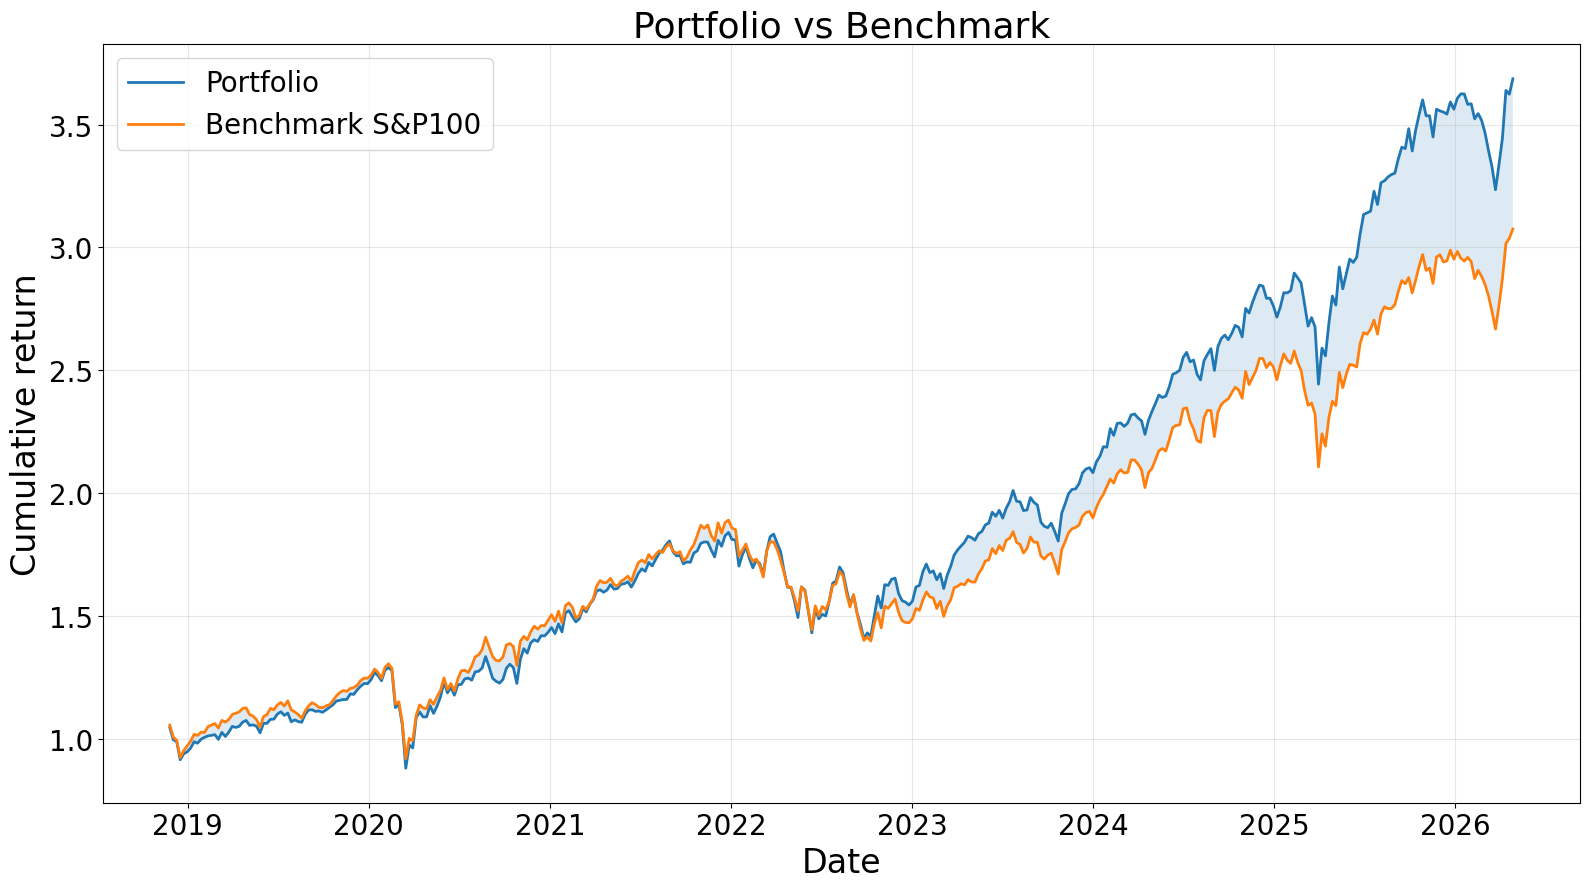

In [87]:
import matplotlib.pyplot as plt

oos_dates = returns.index[rebalance_points[0]:rebalance_points[0] + len(all_portfolio_returns)]

cum_port = (1 + all_portfolio_returns).cumprod()
cum_bench = (1 + all_benchmark_returns).cumprod()

plt.figure(figsize=(16, 9))
plt.plot(oos_dates, cum_port, label='Portfolio', linewidth=2)
plt.plot(oos_dates, cum_bench, label='Benchmark S&P100', linewidth=2)
plt.fill_between(oos_dates, cum_port, cum_bench, alpha=0.15)
plt.title('Portfolio vs Benchmark', fontsize=26)
plt.xlabel('Date', fontsize=24)
plt.ylabel('Cumulative return', fontsize=24)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tracking_portfolio_vs_sp100.png', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
turnover_list = []

for i in range(1, len(rebalance_points)):
    t0 = rebalance_points[i-1]
    t1 = rebalance_points[i]

    rets = asset_returns.iloc[t0:t1]
    w0 = all_weights[i-1]
    w1 = all_weights[i]

    if len(rets) > 1:
        cum_rets = (1 + rets).prod() - 1
        port_ret = (1 + rets.values @ w0).prod() - 1
        w_drifted = w0 * (1 + cum_rets.values) / (1 + port_ret)
    else:
        w_drifted = w0

    to = 0.5 * np.sum(np.abs(w1 - w_drifted))
    turnover_list.append(to)

turnover_arr = np.array(turnover_list)

print('Mean turnover:', round(np.mean(turnover_arr), 4))
print('Median turnover:', round(np.median(turnover_arr), 4))

Mean turnover: 0.5267
Median turnover: 0.639


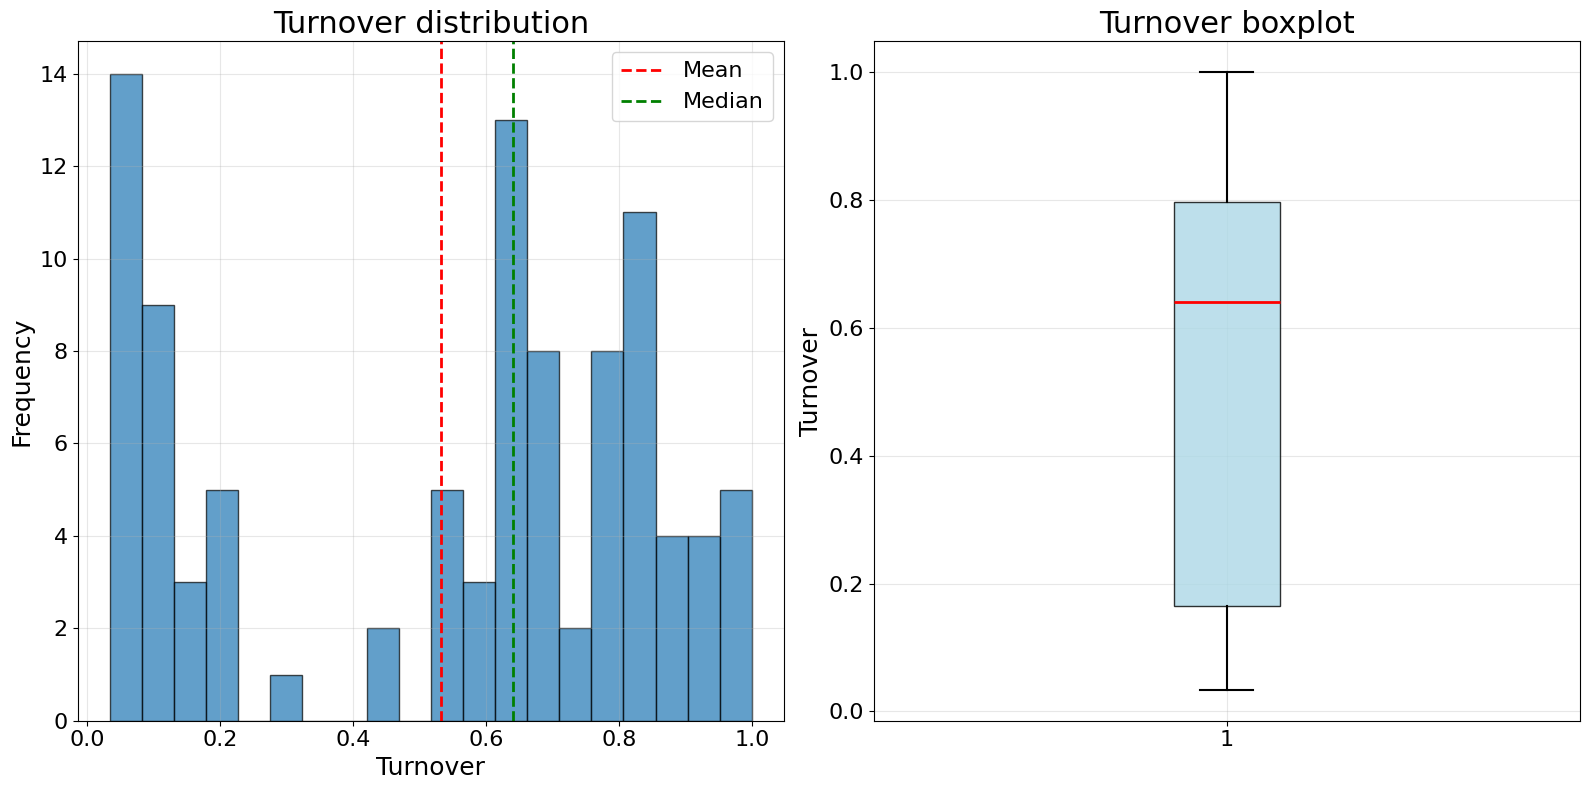

Turnover mean: 0.5317
Turnover median: 0.641
Turnover std: 0.3172
Turnover min: 0.0336
Turnover max: 1.0


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].hist(turnover_arr, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.mean(turnover_arr), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(x=np.median(turnover_arr), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_title('Turnover distribution', fontsize=22)
axes[0].set_xlabel('Turnover', fontsize=18)
axes[0].set_ylabel('Frequency', fontsize=18)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].legend(fontsize=16)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(turnover_arr, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.8),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
axes[1].set_title('Turnover boxplot', fontsize=22)
axes[1].set_ylabel('Turnover', fontsize=18)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('turnover_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Turnover mean:', round(np.mean(turnover_arr), 4))
print('Turnover median:', round(np.median(turnover_arr), 4))
print('Turnover std:', round(np.std(turnover_arr), 4))
print('Turnover min:', round(np.min(turnover_arr), 4))
print('Turnover max:', round(np.max(turnover_arr), 4))

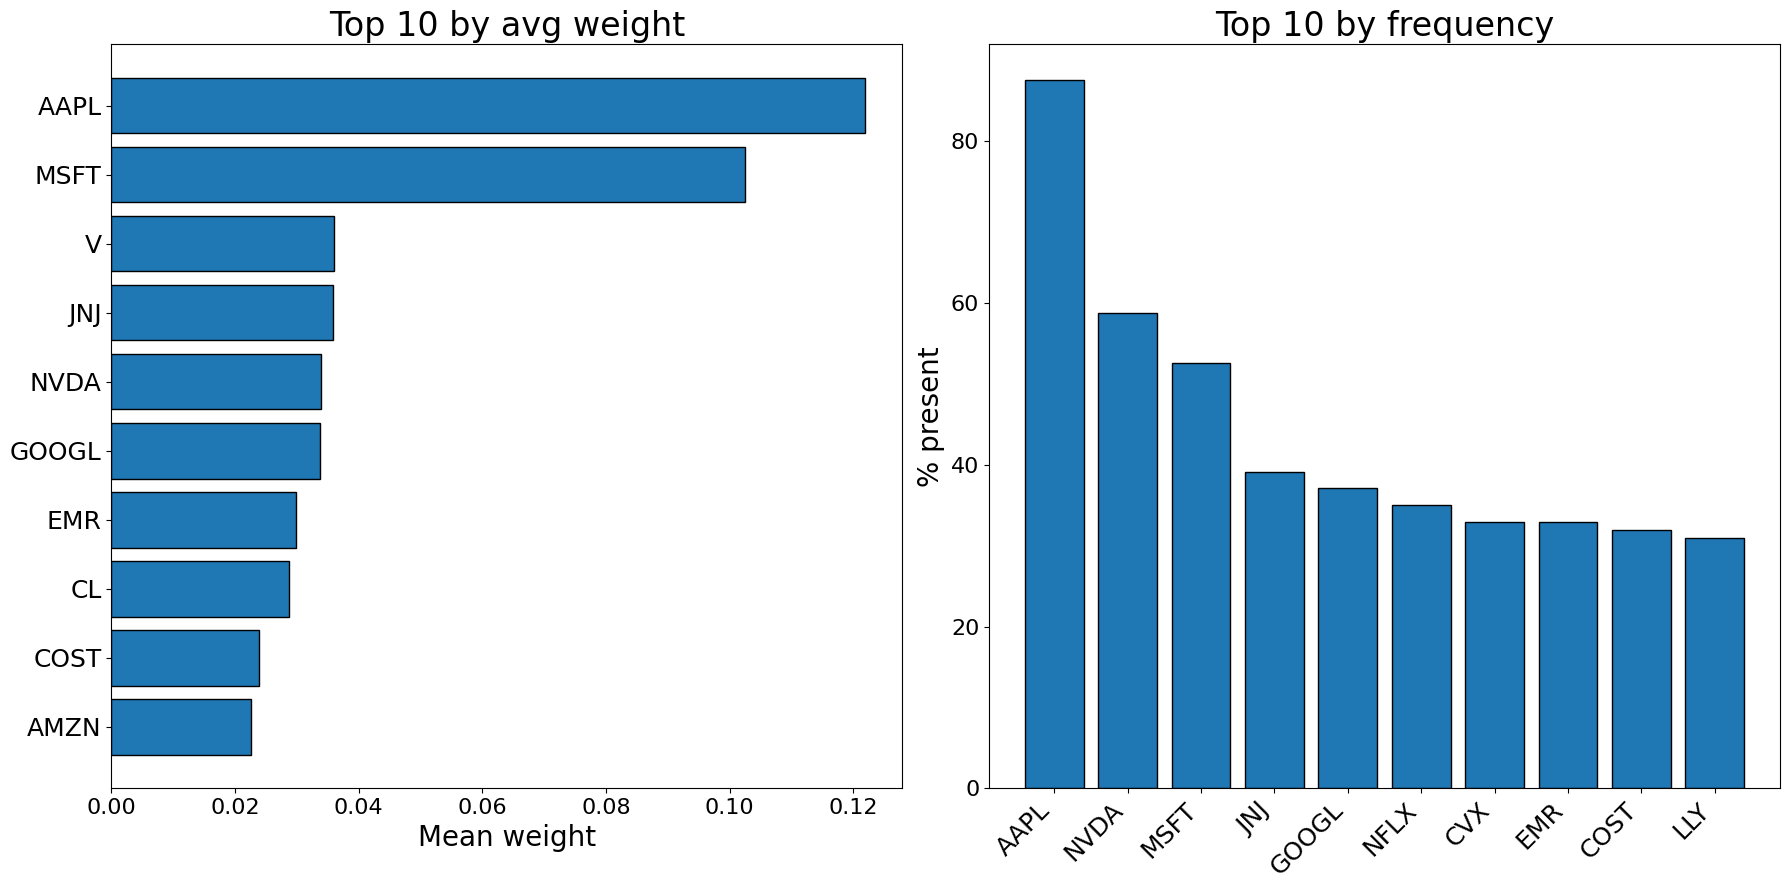

Top 10 by avg weight:
   1 AAPL 0.1219
   2 MSFT 0.1024
   3 V 0.0361
   4 JNJ 0.0358
   5 NVDA 0.0338
   6 GOOGL 0.0338
   7 EMR 0.0299
   8 CL 0.0287
   9 COST 0.0239
   10 AMZN 0.0225

Top 10 by frequency:
   1 AAPL 88%
   2 NVDA 59%
   3 MSFT 53%
   4 JNJ 39%
   5 GOOGL 37%
   6 NFLX 35%
   7 CVX 33%
   8 EMR 33%
   9 COST 32%
   10 LLY 31%


In [97]:
mean_w = np.mean(np.abs(all_weights), axis=0)

top_idx = np.argsort(mean_w)[::-1][:10]
top_tickers = [TICKERS[i] for i in top_idx]
top_w = mean_w[top_idx]

freq = np.mean(np.abs(all_weights) > 1e-5, axis=0)
top_freq_idx = np.argsort(freq)[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

axes[0].barh(range(10), top_w, edgecolor='black')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(top_tickers, fontsize=18)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mean weight', fontsize=20)
axes[0].set_title('Top 10 by avg weight', fontsize=24)
axes[0].tick_params(axis='x', labelsize=16)

top_freq_vals = freq[top_freq_idx]
top_freq_names = [TICKERS[i] for i in top_freq_idx]
axes[1].bar(range(10), top_freq_vals * 100, edgecolor='black')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(top_freq_names, rotation=45, ha='right', fontsize=18)
axes[1].set_ylabel('% present', fontsize=20)
axes[1].set_title('Top 10 by frequency', fontsize=24)
axes[1].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.savefig('top10_stocks.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top 10 by avg weight:')
for i, (t, w) in enumerate(zip(top_tickers, top_w)):
    print('  ', i+1, t, round(w, 4))

print('\nTop 10 by frequency:')
for i, (t, f) in enumerate(zip(top_freq_names, top_freq_vals)):
    print('  ', i+1, t, str(round(f*100)) + '%')

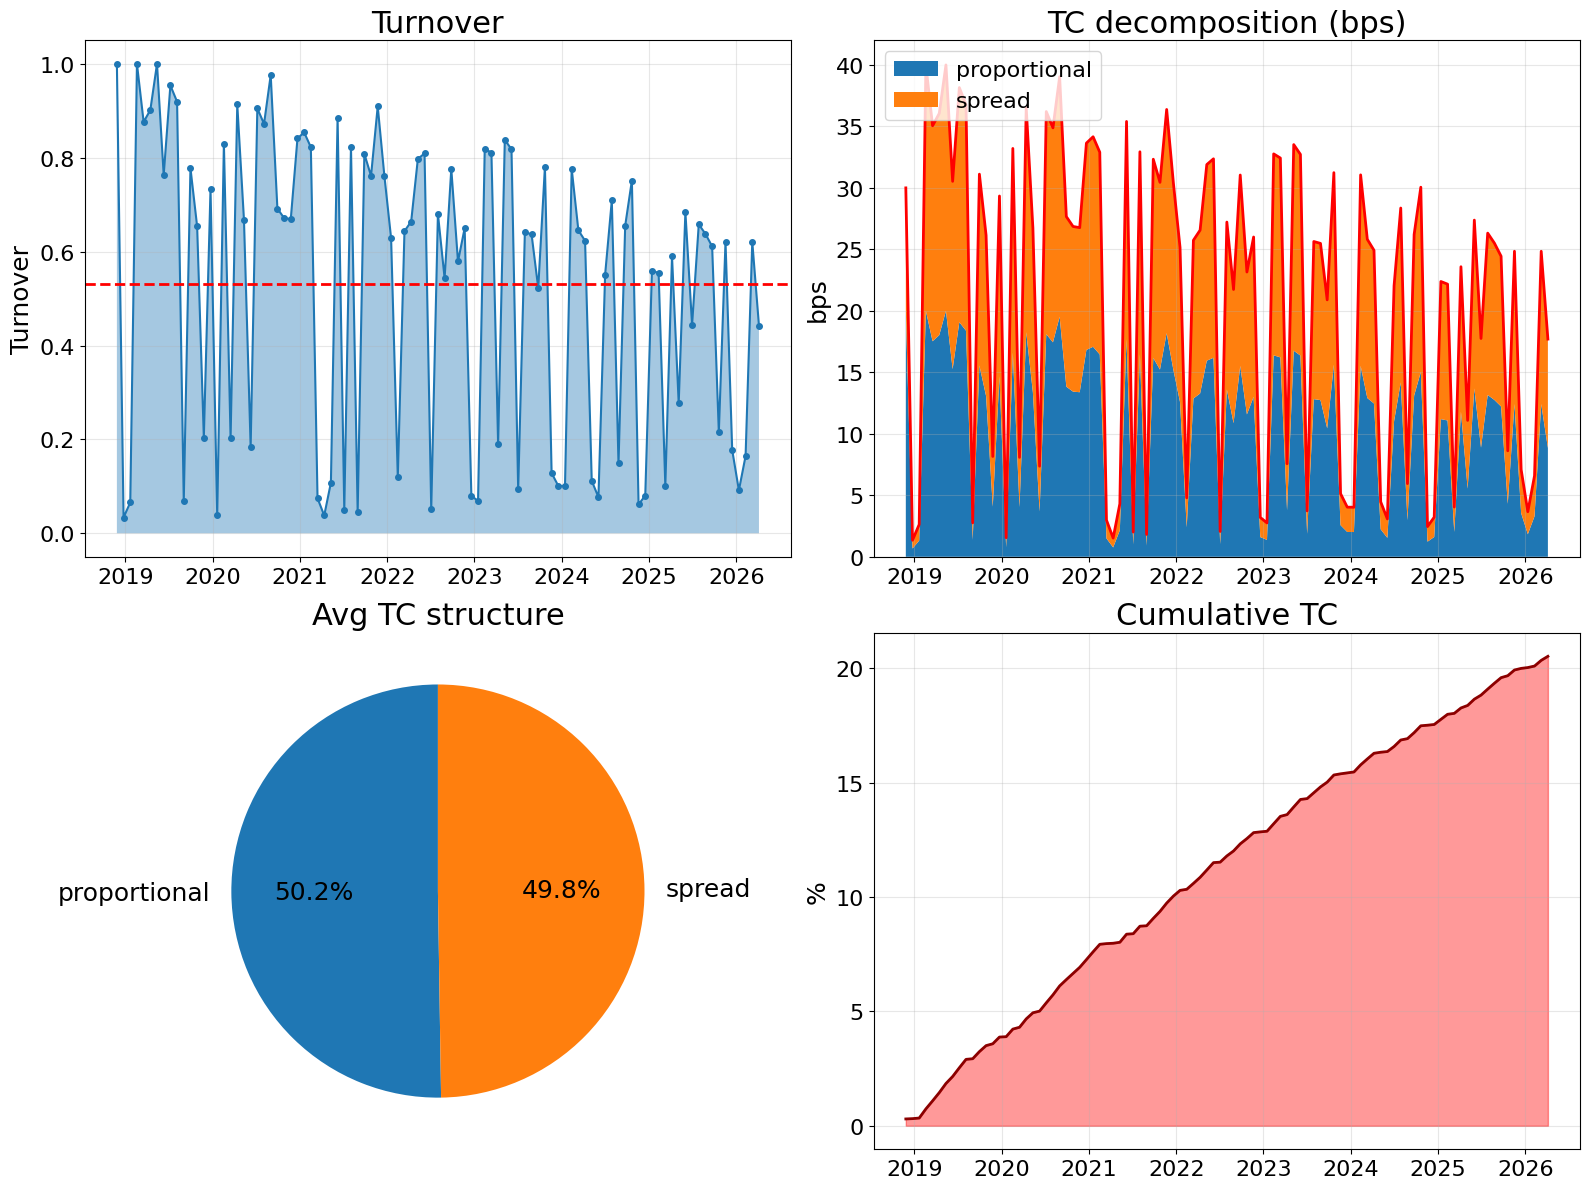

Mean turnover: 0.5317
Median turnover: 0.641
Max turnover: 1.0
Avg prop TC: 10.63 bps
Avg spread TC: 10.53 bps
Avg total TC: 21.16 bps
Total cum TC: 20.53 %
Avg N traded: 19.8


In [100]:
c_prop = 0.002
init_aum = 1000000

turnover_arr = []
tc_prop_arr = []
tc_spread_arr = []
tc_total_arr = []
aum_arr = []
n_traded_arr = []

curr_aum = init_aum

for i, t in enumerate(rebalance_points):
    test_end = min(t + REBALANCE_FREQ, len(returns))
    w_curr = all_weights[i]

    if i == 0:
        to = np.sum(np.abs(w_curr))
        dw = w_curr.copy()
    else:
        w_prev = all_weights[i-1]
        rets_prev = asset_returns.iloc[rebalance_points[i-1]:t]
        cum_rets = (1 + rets_prev).prod() - 1
        w_drifted = w_prev * (1 + cum_rets.values)
        w_drifted = w_drifted / np.sum(w_drifted)
        dw = w_curr - w_drifted
        to = 0.5 * np.sum(np.abs(dw))

    turnover_arr.append(to)

    n_tr = np.sum(np.abs(dw) > 1e-6)
    n_traded_arr.append(n_tr)

    tc_prop = c_prop * to
    tc_prop_arr.append(tc_prop)

    rho = np.full(len(w_curr), 0.001)
    tc_spr = np.sum(rho * np.abs(dw))
    tc_spread_arr.append(tc_spr)

    tc_tot = tc_prop + tc_spr
    tc_total_arr.append(tc_tot)

    rets_test = asset_returns.iloc[t:test_end]
    port_ret = np.prod(1 + rets_test.values @ w_curr) - 1
    curr_aum = curr_aum * (1 + port_ret - tc_tot)
    aum_arr.append(curr_aum)

turnover_arr = np.array(turnover_arr)
tc_prop_arr = np.array(tc_prop_arr)
tc_spread_arr = np.array(tc_spread_arr)
tc_total_arr = np.array(tc_total_arr)
aum_arr = np.array(aum_arr)
n_traded_arr = np.array(n_traded_arr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].fill_between(rebalance_dates, 0, turnover_arr, alpha=0.4)
axes[0, 0].plot(rebalance_dates, turnover_arr, marker='o', markersize=4)
axes[0, 0].axhline(y=np.mean(turnover_arr), color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Turnover', fontsize=22)
axes[0, 0].set_ylabel('Turnover', fontsize=18)
axes[0, 0].tick_params(axis='both', labelsize=16)
axes[0, 0].grid(True, alpha=0.3)

tc_stack = np.column_stack([tc_prop_arr*10000, tc_spread_arr*10000])
axes[0, 1].stackplot(rebalance_dates, tc_stack.T, labels=['proportional', 'spread'])
axes[0, 1].plot(rebalance_dates, tc_total_arr*10000, color='red', linewidth=2)
axes[0, 1].set_title('TC decomposition (bps)', fontsize=22)
axes[0, 1].set_ylabel('bps', fontsize=18)
axes[0, 1].tick_params(axis='both', labelsize=16)
axes[0, 1].legend(loc='upper left', fontsize=16)
axes[0, 1].grid(True, alpha=0.3)

tc_pie = [np.mean(tc_prop_arr), np.mean(tc_spread_arr)]
axes[1, 0].pie(tc_pie, labels=['proportional', 'spread'], autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 18})
axes[1, 0].set_title('Avg TC structure', fontsize=22)

cum_tc = np.cumsum(tc_total_arr) * 100
axes[1, 1].fill_between(rebalance_dates, 0, cum_tc, alpha=0.4, color='red')
axes[1, 1].plot(rebalance_dates, cum_tc, color='darkred', linewidth=2)
axes[1, 1].set_title('Cumulative TC', fontsize=22)
axes[1, 1].set_ylabel('%', fontsize=18)
axes[1, 1].tick_params(axis='both', labelsize=16)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transaction_costs.png', dpi=300, bbox_inches='tight')
plt.show()

print('Mean turnover:', round(np.mean(turnover_arr), 4))
print('Median turnover:', round(np.median(turnover_arr), 4))
print('Max turnover:', round(np.max(turnover_arr), 4))
print('Avg prop TC:', round(np.mean(tc_prop_arr)*10000, 2), 'bps')
print('Avg spread TC:', round(np.mean(tc_spread_arr)*10000, 2), 'bps')
print('Avg total TC:', round(np.mean(tc_total_arr)*10000, 2), 'bps')
print('Total cum TC:', round(np.sum(tc_total_arr)*100, 2), '%')
print('Avg N traded:', round(np.mean(n_traded_arr), 1))
